# 📌 Project Overview

This project focuses on predicting hotel booking cancellations using Machine Learning models.

The goal is to build a robust pipeline that:
- Preprocesses mixed data (numerical + categorical)
- Applies optional feature selection
- Trains multiple models
- Compares their performance using evaluation metrics and visualizations

We experiment with **four different pipelines**:
- Models with Feature Selection
- Models without Feature Selection

This allows us to clearly evaluate the impact of feature selection on model performance.

The dataset used contains hotel reservation information, and the target variable is:
- `booking_status` → (Canceled = 1, Not_Canceled = 0)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,
                             precision_score,
                              recall_score,
                              f1_score, roc_auc_score,
                              confusion_matrix,
                              ConfusionMatrixDisplay,
                              RocCurveDisplay
                              )
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings("ignore")

SEED = 42

## ⚙️ Data Preprocessing

In this stage, we prepare the dataset for training.

#### Steps performed:
1. **Splitting the data**
   - Train/Test split (80% training, 20% testing)
   - Stratified sampling to preserve class distribution

2. **Handling Numerical Features**
   - Missing values → filled using **median**
   - Scaling → using **StandardScaler**

3. **Handling Categorical Features**
   - Missing values → filled using **most frequent value**
   - Encoding → using **One-Hot Encoding**

4. **ColumnTransformer**
   - Combines numerical and categorical preprocessing into one pipeline

This ensures that:
- No data leakage occurs
- All transformations are applied consistently during training and testing

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Hotel Reservations.csv")

X = df.drop(columns=["Booking_ID", "booking_status"], errors="ignore")
y = df["booking_status"].map(
    {
        "Canceled": 1,
        "Not_Canceled": 0
        }
    ).astype("int64")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
) # 4 output

In [ ]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]


preprocessor = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]),
        num_cols,
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]),
        cat_cols,
    ),
])
preprocessor.set_output(transform="pandas")
print("preprocessing is Done✅")

preprocessing is Done✅


In [ ]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['no_of_adults', 'no_of_children',
                                  'no_of_weekend_nights', 'no_of_week_nights',
                                  'required_car_parking_space', 'lead_time',
                                  'arrival_year', 'arrival_month',
                                  'arrival_date', 'repeated_guest',
                                  'no_of_previous_cancellations',
                                  'no_of_previous_bookings_not_canceled',
                                  'avg_price_per_room',
                                  'no_of_special_requests']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['type_of_meal_plan', 'room_type_reserved',
                                  'market_segment_type'])])

## 🎯 Feature Selection & Model Creation

In this stage, we apply **Feature Selection** and define our Machine Learning models.

---

### 🔹 Feature Selection

We use **Logistic Regression with L1 Regularization (Lasso)** inside `SelectFromModel`.

#### Why Feature Selection?
- Reduces irrelevant features (noise)
- Improves generalization
- Helps prevent overfitting
- Speeds up training

#### Method Used:
- Logistic Regression with:
  - `penalty = elasticnet` (L1 dominant)
  - `l1_ratio = 1.0` (pure L1 behavior)
- Selects the **top 28 most important features**

---

### 🤖 Models Used

We use two powerful gradient boosting models:

#### 1. XGBoost
- Handles complex patterns
- High performance on structured/tabular data
- Uses histogram-based optimization (`tree_method="hist"`)

#### 2. LightGBM
- Faster and more efficient
- Works well with large datasets
- Uses leaf-wise tree growth

---

### ⚡ Hyperparameter Optimization

The parameters used in both models are **optimized using Optuna**.

- Optuna automatically searches for the best hyperparameters
- Goal: maximize model performance
- The current values represent the **best configuration found**

---

### 🧪 Experiment Idea

We will later compare:
- Models **with Feature Selection**
- Models **without Feature Selection**

This helps us answer:
👉 *Does Feature Selection actually improve performance?*

In [ ]:
# Feature Selection
l1_selector = SelectFromModel(
    LogisticRegression(
        solver="saga",
        penalty="elasticnet",
        l1_ratio=1.0,
        C=0.5,
        random_state=SEED,
        max_iter=3000,
    ),
    threshold=-np.inf,
    max_features=28,
)

# Models
## XGBOOST Model
xgb_best = XGBRegressor(
    n_estimators=350,
    max_depth=8,
    learning_rate=0.12028665880905137,
    subsample=0.8795975452591109,
    colsample_bytree=0.7468055921327309,
    random_state=SEED,
    n_jobs=-1,
    tree_method="hist",
    objective="binary:logistic",
)

## LightGBM Model
lgbm_best = LGBMClassifier(
    n_estimators=501,
    max_depth= 12,
    num_leaves= 73,
    learning_rate= 0.031194713369389154,
    random_state=SEED,
    n_jobs=-1,
)

print("Creation of the Models is Done✅")

Creation of the Models is Done✅


## 🔗 Pipelines, Training & Evaluation

In this stage, we build pipelines, train models, and evaluate performance.

---

###🔹 Pipeline Construction

We use `sklearn.pipeline.Pipeline` to organize the workflow.

Each pipeline includes:
- Data preprocessing
- (Optional) Feature Selection
- Model training

---

### 🧱 Pipelines Created

We define **4 different pipelines**:

1. **XGBoost with Feature Selection**
   - Preprocessing → Feature Selection → XGBoost

2. **LightGBM with Feature Selection**
   - Preprocessing → Feature Selection → LightGBM

3. **XGBoost without Feature Selection**
   - Preprocessing → XGBoost

4. **LightGBM without Feature Selection**
   - Preprocessing → LightGBM

---

### ✅ Why Pipelines?

- Prevent data leakage
- Ensure consistent transformations
- Simplify experimentation
- Make the workflow clean and reproducible

---

### 🚀 Training Process

- Each pipeline is trained on the training dataset
- Predictions are generated on the test dataset

#### Predictions Handling:
- Model outputs scores (probabilities or predictions)
- Converted to binary values using threshold = 0.5

---

### 📊 Evaluation Metrics

We evaluate each model using:

- **Accuracy** → Overall correctness
- **Precision** → Quality of positive predictions
- **Recall** → Ability to detect positives
- **F1-Score** → Balance between Precision & Recall
- **ROC-AUC** → Model’s ability to distinguish classes

---

### 📌 Output Storage

For each model, we store:
- Predictions
- Scores (probabilities)
- Metrics in DataFrame format

This allows easy comparison and visualization in later steps.

In [ ]:
#1 For Loop To Piplines about Lr Selection
pipelines = {
    "XGB_with_FS": Pipeline([
        ("preprocessor", preprocessor),
        ("selector", l1_selector),
        ("model", xgb_best)
    ]),

    "LGBM_with_FS": Pipeline([
        ("preprocessor", preprocessor),
        ("selector", l1_selector),
        ("model", lgbm_best)
    ]),

    "XGB": Pipeline([
        ("preprocessor", preprocessor),
        ("model", xgb_best)
    ]),

    "LGBM": Pipeline([
        ("preprocessor", preprocessor),
        ("model", lgbm_best)
    ])
}

model_names = [
    "XGB_with_Selection",
    "LightGBM_with_Selection",
    "XGB",
    "LightGBM"
]

results = {}
predictions = {}
scores = {}

for name, pipe in pipelines.items():
    print(f"Training {name}...")

    pipe.fit(X_train, y_train)

    y_score = pipe.predict(X_test)
    y_pred = (y_score >= 0.5).astype(int)

    predictions[name] = y_pred
    scores[name] = y_score

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_score)
    }

    print(results[name])
    print(f"{name} Done ✅\n")




Training XGB_with_FS...
{'Accuracy': 0.9031013094417643, 'Precision': 0.8736607142857142, 'Recall': 0.8233066891039125, 'F1': 0.8477366255144033, 'ROC-AUC': np.float64(0.9586557781858844)}
XGB_with_FS Done ✅

Training LGBM_with_FS...
[LightGBM] [Info] Number of positive: 9508, number of negative: 19512
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.072383 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 677
[LightGBM] [Info] Number of data points in the train set: 29020, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.327636 -> initscore=-0.718896
[LightGBM] [Info] Start training from score -0.718896
{'Accuracy': 0.9022742935906272, 'Precision': 0.875, 'Recall': 0.8186790071518721, 'F1': 0.8459030645511846, 'ROC-AUC': np.float64(0.8808442186230865)}
LGBM_with_FS Done ✅

Training XGB...
{'Accuracy': 0.901860

In [ ]:
results_df = pd.DataFrame(results).T
display(results_df)

,Accuracy,Precision,Recall,F1,ROC-AUC
XGB_with_FS,0.903101,0.873661,0.823307,0.847737,0.958656
LGBM_with_FS,0.902274,0.875000,0.818679,0.845903,0.880844
XGB,0.901861,0.869836,0.823727,0.846154,0.959329
LGBM,0.902274,0.873991,0.819941,0.846104,0.881168


## 📊 visualization Part

### 📊 Accuracy Comparison

This visualization compares the **accuracy of all models**.

---

#### 🎯 Purpose

- Identify the best-performing model based on Accuracy
- Evaluate the impact of Feature Selection on performance

---

#### 🔍 What to Observe

- Does Feature Selection improve model performance?
- The difference between **XGBoost** and **LightGBM**
- Which model achieves the highest accuracy

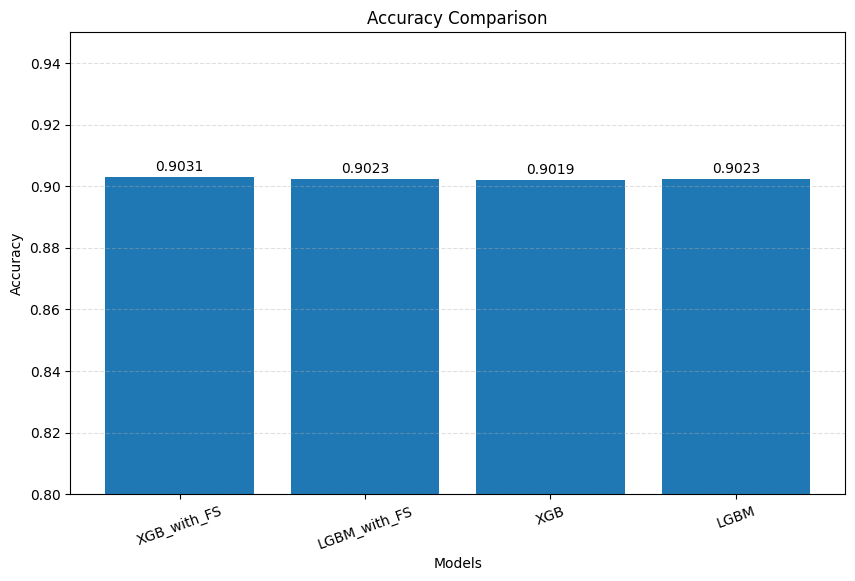

In [ ]:
plt.figure(figsize=(10,6))

bars = plt.bar(results_df.index, results_df["Accuracy"])

plt.ylim(0.80, 0.95)
plt.title("Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha = 0.4)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h+0.002, f"{h:.4f}", ha="center")

plt.show()

### 📈 Metrics Comparison

This grouped bar chart compares all models across multiple evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-Score

---

#### 🎯 Purpose

- Provide a comprehensive comparison between models
- Go beyond accuracy to evaluate real model performance

---

#### 🔍 What to Look For

- Is there a well-balanced model?
- Does any model have high Precision but low Recall?
- Which model provides the best trade-off between metrics?

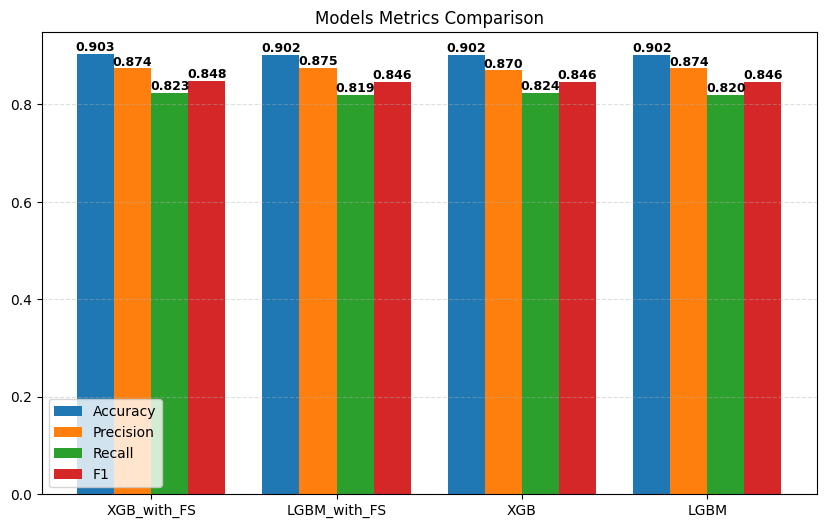

In [ ]:

x = np.arange(len(results_df))
width = 0.2

plt.figure(figsize=(10,6))

bars1 = plt.bar(x - 1.5 * width, results_df["Accuracy"], width, label="Accuracy")
bars2 = plt.bar(x - 0.5 * width, results_df["Precision"], width, label="Precision")
bars3 = plt.bar(x + 0.5 * width, results_df["Recall"], width, label="Recall")
bars4 = plt.bar(x + 1.5 * width, results_df["F1"], width, label="F1")

all_bars = [bars1, bars2, bars3, bars4]
for group in all_bars:
    for bar in group:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

plt.xticks(x, results_df.index)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha = 0.4)
plt.title("Models Metrics Comparison")

plt.show()

### 🔍 Model Evaluation Visualization

We use two important visual tools to better understand model performance.

---

#### 1. Confusion Matrix

##### 📊 Shows:
- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

##### 📌 Helps Understand:
- The types of errors the model makes
- Whether the model is biased toward a specific class

---

#### 2. ROC Curve

##### 📈 Shows:
- Relationship between:
  - True Positive Rate (TPR)
  - False Positive Rate (FPR)

##### 📌 Helps Understand:
- The model’s ability to distinguish between classes
- The closer the curve is to the top-left corner → the better the model

---

#### 🎯 Overall Goal

- Evaluate the model visually
- Understand model behavior beyond numerical metrics

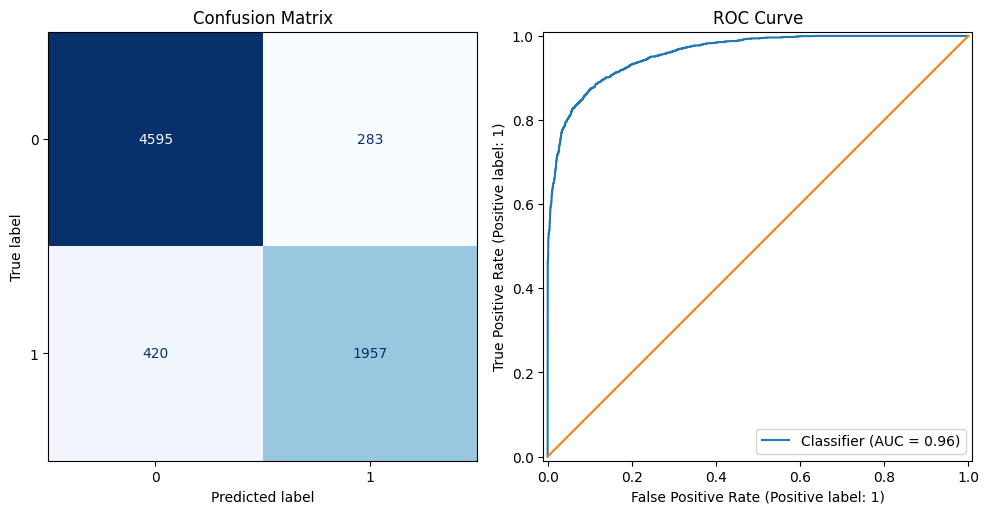

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,6))

best_model = "XGB_with_FS"

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions[best_model],
    ax=axes[0],
    cmap="Blues",
    colorbar=False
)
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(
    y_test,
    scores[best_model],
    ax=axes[1]
)
axes[1].plot([0,1],[0,1])
axes[1].set_title("ROC Curve")

plt.tight_layout()
plt.show()